##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:


# 1. Import Libraries

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

from transformers import ViTModel, AutoImageProcessor
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix


# 2. Load Pretrained ViT Model
model_name = "facebook/dino-vits16"

processor = AutoImageProcessor.from_pretrained(model_name)
model = ViTModel.from_pretrained(model_name)

model.eval()



# 3. Load Oxford-IIIT Pet Dataset
dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=True
)


# 4. Define Cat and Dog Labels
# Oxford Pet classes:
# 0-11 are cats, 12-36 are dogs
def get_binary_label(class_id):
    if class_id <= 11:
        return 0   # Cat
    else:
        return 1   # Dog


# 5. Select 20 Images: Mix of Cats and Dogs
cat_indices = []
dog_indices = []

for idx in range(len(dataset)):
    _, label = dataset[idx]
    
    if label <= 11 and len(cat_indices) < 10:
        cat_indices.append(idx)
    elif label > 11 and len(dog_indices) < 10:
        dog_indices.append(idx)
    
    if len(cat_indices) == 10 and len(dog_indices) == 10:
        break

selected_indices = cat_indices + dog_indices

images = []
true_labels = []

for idx in selected_indices:
    image, label = dataset[idx]
    images.append(image)
    true_labels.append(get_binary_label(label))

true_labels = np.array(true_labels)


# 6. Extract 384-Dimensional CLS Tokens
cls_tokens = []

with torch.no_grad():
    for image in images:
        inputs = processor(images=image, return_tensors="pt")
        outputs = model(**inputs)

        # CLS token is the first token
        cls_token = outputs.last_hidden_state[:, 0, :]

        cls_tokens.append(cls_token.squeeze().numpy())

cls_tokens = np.array(cls_tokens)

print("CLS Tokens Shape:", cls_tokens.shape)

# 7. Apply K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
predicted_clusters = kmeans.fit_predict(cls_tokens)

# 8. Compare Clusters with Ground Truth Labels
# KMeans cluster numbers may be flipped, so we test both possibilities
accuracy_1 = accuracy_score(true_labels, predicted_clusters)
accuracy_2 = accuracy_score(true_labels, 1 - predicted_clusters)

final_accuracy = max(accuracy_1, accuracy_2)

if accuracy_2 > accuracy_1:
    predicted_clusters = 1 - predicted_clusters

# 9. Display Results
results = pd.DataFrame({
    "Image Number": range(1, 21),
    "True Label": ["Cat" if label == 0 else "Dog" for label in true_labels],
    "Predicted Cluster": ["Cat" if cluster == 0 else "Dog" for cluster in predicted_clusters]
})

print(results)
print("\nClustering Accuracy:", final_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_clusters))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/86.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: facebook/dino-vits16
Key                 | Status  | 
--------------------+---------+-
pooler.dense.weight | MISSING | 
pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/86.7M [00:00<?, ?B/s]

100%|██████████| 792M/792M [01:07<00:00, 11.7MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 7.38MB/s]


CLS Tokens Shape: (20, 384)
    Image Number True Label Predicted Cluster
0              1        Cat               Cat
1              2        Cat               Cat
2              3        Cat               Cat
3              4        Cat               Cat
4              5        Cat               Cat
5              6        Cat               Cat
6              7        Cat               Cat
7              8        Cat               Cat
8              9        Cat               Cat
9             10        Cat               Cat
10            11        Dog               Dog
11            12        Dog               Dog
12            13        Dog               Dog
13            14        Dog               Dog
14            15        Dog               Dog
15            16        Dog               Dog
16            17        Dog               Dog
17            18        Dog               Dog
18            19        Dog               Dog
19            20        Dog               Dog

Clust

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [4]:
# Mount Google Drive
drive.mount('/content/drive')


NameError: name 'drive' is not defined

Loading processor...


The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading model weights... Please wait.


Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Model weights loaded successfully: 100%
Loading image...
Running inference...
Predicted Class ID: 779
Predicted Label: school bus


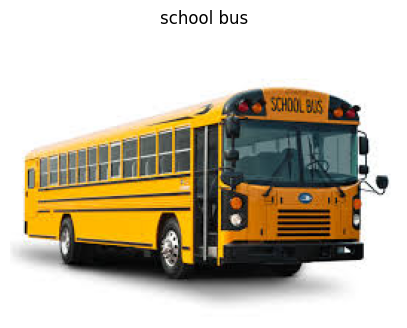

In [5]:
# Import Libraries
import torch
from PIL import Image
import matplotlib.pyplot as plt

from transformers import AutoImageProcessor, AutoModelForImageClassification

# Load Model
model_id = "facebook/dinov2-small-imagenet1k-1-layer"

print("Loading processor...")
processor = AutoImageProcessor.from_pretrained(model_id)

print("Loading model weights... Please wait.")
model = AutoModelForImageClassification.from_pretrained(model_id)

print("Model weights loaded successfully: 100%")

# Set Model to Evaluation Mode
model.eval()

# Load Image
image_path = "/content/drive/MyDrive/Colab Notebooks/school_bus.jpeg"

print("Loading image...")
image = Image.open(image_path).convert("RGB")

# Preprocess Image
inputs = processor(images=image, return_tensors="pt")

# Perform Inference
print("Running inference...")

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class_id = logits.argmax(-1).item()

# Get Predicted Label
predicted_label = model.config.id2label[predicted_class_id]

# Print Results
print("Predicted Class ID:", predicted_class_id)
print("Predicted Label:", predicted_label)

# Display Image
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(predicted_label)
plt.show()